# 4 · Hands-on: $g^{(2)}$ from Click Data

**Interactive session · Tuesday July 28, 10:30–11:30 · work in pairs**

Three simulated Hanbury Brown–Twiss measurements, straight from the (virtual) time tagger: `source_A`, `source_B`, `source_C`. One is a **laser**, one a **thermal source**, one a **single quantum emitter** — and the file names won't tell you which.

**Your mission: identify all three from the raw time tags, with quantitative evidence.**

### Learning objectives

1. compute $g^{(2)}(\tau)$ from raw time tags via a coincidence histogram,
2. classify unknown light sources by their photon statistics,
3. quantify how uncorrelated **background** degrades an antibunching measurement.

### The data

Each `.npz` file contains an HBT recording (50:50 beamsplitter, one detector per arm, 10 s of data, ~25 000 detected photons/s total, plus realistic dark counts and timing jitter):

| array | meaning |
|---|---|
| `t1` | detector-1 arrival times, **integer nanoseconds**, sorted |
| `t2` | detector-2 arrival times, integer nanoseconds, sorted |
| `duration_ns` | total measurement time in ns |

*(The generator script is [`data/make_timetags.py`](../data/make_timetags.py) — reading it won't spoil the answer, the assignment is shuffled by the random seed.)*

In [1]:
# Setup + data loading. Works in Codespaces (files are in the repo)
# and on Google Colab (downloads the files from GitHub on first run).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import qutip

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})

# Where the data lives relative to this notebook; falls back to GitHub raw.
GITHUB_REPO = "laserlab/CountingPhotons"   # <- adjust if the course repo moves
DATA_DIR = "../data" if os.path.isdir("../data") else "data"

def load_source(letter: str) -> dict:
    """Load one HBT time-tag recording, downloading it if necessary.

    Returns a dict with t1, t2 (int64 nanoseconds, sorted) and
    duration_ns (float).
    """
    fname = f"source_{letter}_timetags.npz"
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        url = (f"https://raw.githubusercontent.com/{GITHUB_REPO}"
               f"/main/data/{fname}")
        print("downloading", url)
        urllib.request.urlretrieve(url, path)
    d = np.load(path)
    return {"t1": d["t1"].astype(np.int64),   # int64: we will subtract times!
            "t2": d["t2"].astype(np.int64),
            "duration_ns": float(d["duration_ns"])}

sources = {letter: load_source(letter) for letter in "ABC"}
for letter, d in sources.items():
    rate_kcps = (d["t1"].size + d["t2"].size) / d["duration_ns"] * 1e6
    print(f"source_{letter}: {d['t1'].size:6d} + {d['t2'].size:6d} tags, "
          f"{rate_kcps:5.1f} kcps total")

source_A: 127119 + 127211 tags,  25.4 kcps total
source_B: 126750 + 127132 tags,  25.4 kcps total
source_C: 127110 + 126549 tags,  25.4 kcps total


Same count rate everywhere — a power meter is useless here, as promised.

## Worked example: the coincidence histogram

$g^{(2)}(\tau)$ from time tags, in words:

1. for every click on detector 1, find all detector-2 clicks within $\pm\tau_{\max}$ (fast because the arrays are sorted → `np.searchsorted`),
2. histogram the time differences $\Delta t = t_2 - t_1$ in bins of width $\Delta\tau$,
3. **normalize** by what uncorrelated streams would give: $N_{\rm acc} = r_1 r_2 T \Delta\tau$ coincidences per bin, where $r_i$ are the count rates and $T$ the total time. Dividing by $N_{\rm acc}$ makes flat = 1, so the histogram becomes $g^{(2)}(\tau)$.

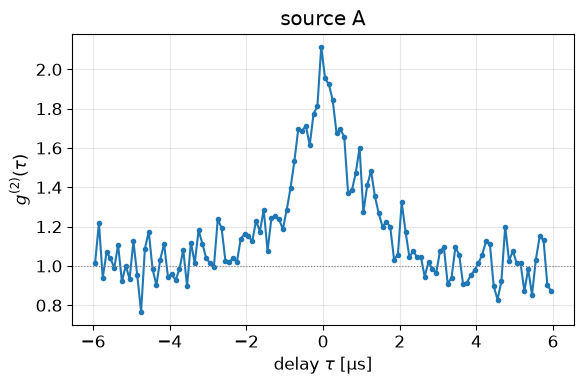

In [2]:
def g2_from_timetags(t1: np.ndarray, t2: np.ndarray, duration_ns: float,
                     window_ns: int = 6000, bin_ns: int = 100):
    """Normalized coincidence histogram g2(tau) from two HBT tag streams.

    Parameters
    ----------
    t1, t2 : sorted int64 arrays, arrival times [ns]
    duration_ns : total measurement time [ns]
    window_ns : histogram spans -window .. +window [ns]
    bin_ns : histogram bin width [ns]

    Returns
    -------
    tau_ns : bin centers [ns]
    g2 : normalized coincidence counts (dimensionless, ->1 for tau -> inf)
    """
    edges = np.arange(-window_ns, window_ns + bin_ns, bin_ns)
    counts = np.zeros(len(edges) - 1)
    # indices of the first/last t2 partner within the window, per t1 click
    lo = np.searchsorted(t2, t1 - window_ns)
    hi = np.searchsorted(t2, t1 + window_ns)
    for i, (a, b) in enumerate(zip(lo, hi)):
        if b > a:
            counts += np.histogram(t2[a:b] - t1[i], bins=edges)[0]
    # accidental (uncorrelated) coincidences per bin: r1 * r2 * T * bin
    accidentals = (t1.size / duration_ns) * (t2.size / duration_ns) \
        * duration_ns * bin_ns
    tau_ns = edges[:-1] + bin_ns / 2
    return tau_ns, counts / accidentals

# Try it on source A:
d = sources["A"]
tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"])
plt.plot(tau / 1000, g2, ".-")
plt.axhline(1, color="gray", ls=":", lw=0.8)
plt.xlabel(r"delay $\tau$ [µs]")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.title("source A")
plt.tight_layout()
plt.show()

## Exercise 1 · All three sources

Compute and plot $g^{(2)}(\tau)$ for **all three sources** in one figure (shared axes, labeled). Then extract for each:

* $g^{(2)}(0)$ — average the central few bins,
* the correlation time — eyeballing is fine (at which $|\tau|$ is the feature gone?).

In [3]:
# YOUR CODE HERE - Exercise 1
# one figure, three g2(tau) curves + a table of g2(0) values


## Exercise 2 · The verdict

Fill in (markdown cell — double-click):

| source | $g^{(2)}(0)$ | correlation time | identity | key evidence |
|---|---|---|---|---|
| A | | | | |
| B | | | | |
| C | | | | |

*Cross-check with theory:* the single-mode predictions are $2$, $1$, and $\approx 0$. If your emitter's $g^{(2)}(0)$ is *not* $\approx 0$ — is that physics or is that your histogram? Re-run with `bin_ns=20` on the antibunched source before you blame the source. (Remember from the lecture: dark counts also push $g^{(2)}(0)$ up. Both effects are in this data.)

*(double-click to edit — your table here)*

## Exercise 3 · How much background can antibunching survive?

Real measurements sit on uncorrelated background (dark counts, stray light). You will now *add* extra background to the antibunched source and watch the certificate $g^{(2)}(0) < 0.5$ fail.

1. Write `add_background(t, duration_ns, rate_cps, rng)` that merges Poissonian background tags into a stream (keep it sorted!).
2. For background rates from 0 to 20 000 cps *per detector*, recompute $g^{(2)}(0)$ of your antibunched source.
3. Plot $g^{(2)}(0)$ vs background fraction $p = r_{\rm bg}/(r_{\rm bg} + r_{\rm signal})$ and find where it crosses 0.5.

*Theory to compare (worth deriving at home):* with background fraction $p$ per detector, $g^{(2)}_{\rm meas}(0) \approx g^{(2)}_{\rm true}(0)(1-p)^2 + 2p(1-p) + p^2\,$.

In [4]:
# YOUR CODE HERE - Exercise 3
rng = np.random.default_rng(1)

# def add_background(t, duration_ns, rate_cps, rng): ...


## Cross-check with QuTiP (worked)

The time-tag estimate should agree with the operator expectation value $g^{(2)}(0) = \langle \hat n(\hat n-1)\rangle/\langle\hat n\rangle^2$ for the matching states:

In [5]:
def g2_zero_state(state) -> float:
    """g2(0) of a single-mode QuTiP state (ket or density matrix)."""
    n_op = qutip.num(state.shape[0])
    mean_n = qutip.expect(n_op, state)
    return qutip.expect(n_op * (n_op - 1), state) / mean_n**2

N = 40
print("QuTiP single-mode predictions:")
print(f"  thermal (any nbar): g2(0) = {g2_zero_state(qutip.thermal_dm(N, 2.0)):.3f}")
print(f"  coherent (any α):   g2(0) = {g2_zero_state(qutip.coherent(N, 2.0)):.3f}")
print(f"  Fock |1>:           g2(0) = {g2_zero_state(qutip.fock(N, 1)):.3f}")

QuTiP single-mode predictions:
  thermal (any nbar): g2(0) = 2.000
  coherent (any α):   g2(0) = 1.000
  Fock |1>:           g2(0) = 0.000


## Hand in your work (today for real!)

```bash
mkdir -p submissions/<your-github-username>
cp lectures/04_HandsOn_g2_HBT.ipynb submissions/<your-github-username>/
git add submissions/ && git commit -m "Lecture 4: mystery sources identified" && git push
```
On Colab: **File ▸ Save a copy in GitHub** → your fork → path `submissions/<your-username>/04_HandsOn_g2_HBT.ipynb`.

Optional: open a Pull Request to the course repo — tomorrow we discuss the identifications together.

---
---

# Sample solutions

**No peeking during the session.**

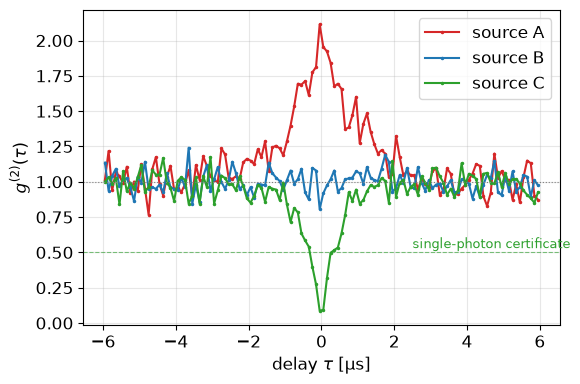

source A: g2(0) = 1.90
source B: g2(0) = 0.98
source C: g2(0) = 0.28


In [6]:
# Solution - Exercise 1
fig, ax = plt.subplots()
g2_zero_values = {}
for letter, color in zip("ABC", ["tab:red", "tab:blue", "tab:green"]):
    d = sources[letter]
    tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"])
    ax.plot(tau / 1000, g2, ".-", ms=3, color=color, label=f"source {letter}")
    g2_zero_values[letter] = g2[np.abs(tau) < 300].mean()
ax.axhline(1, color="gray", ls=":", lw=0.8)
ax.axhline(0.5, color="tab:green", ls="--", lw=0.8, alpha=0.6)
ax.annotate("single-photon certificate", (2.5, 0.53), fontsize=9,
            color="tab:green")
ax.set_xlabel(r"delay $\tau$ [µs]"); ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.legend(); plt.tight_layout(); plt.show()

for letter, v in g2_zero_values.items():
    print(f"source {letter}: g2(0) = {v:.2f}")

**Solution — Exercise 2.** With the seed shipped in the repo: **A = thermal** ($g^{(2)}(0)\approx 1.9$, bunching decays over $\sim 2$ µs), **B = coherent** ($g^{(2)}\approx 1$, flat — no structure at any $\tau$), **C = single emitter** ($g^{(2)}(0)\approx 0.3 < 0.5$: certified single-photon source; antibunching recovers over $\sim 2$ µs).

Why is C at 0.3 and not 0? Two honest experimental reasons, both built into the simulation: (i) **finite bin width** — 100 ns bins average over the first stretch of the recovery $g^{(2)}(\tau) = 1-e^{-|\tau|/\tau_r}$ with $\tau_r \approx 1$ µs (re-run with `bin_ns=20`: the center bin drops substantially); (ii) **dark counts** (200 cps/detector here) add a small uncorrelated floor. The *source* is fine — the *measurement* has resolution and background. This distinction is half of experimental quantum optics.

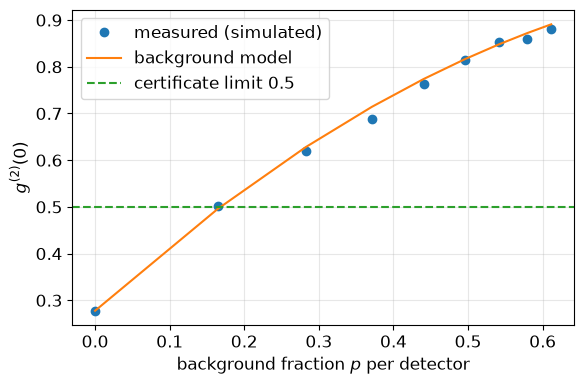

In [7]:
# Solution - Exercise 3
rng = np.random.default_rng(1)

def add_background(t: np.ndarray, duration_ns: float, rate_cps: float,
                   rng: np.random.Generator) -> np.ndarray:
    """Merge uncorrelated Poissonian background clicks into a tag stream.

    Parameters
    ----------
    t : sorted int64 arrival times [ns]
    duration_ns : measurement duration [ns]
    rate_cps : background rate to add [counts/s]
    """
    n_bg = rng.poisson(rate_cps * duration_ns * 1e-9)
    t_bg = rng.integers(0, int(duration_ns), n_bg)
    return np.sort(np.concatenate([t, t_bg]))

d = sources["C"]                       # the antibunched source
signal_rate = d["t1"].size / (d["duration_ns"] * 1e-9)   # cps per detector

bg_rates = np.linspace(0, 20e3, 9)
fractions, g2_measured = [], []
for r_bg in bg_rates:
    t1b = add_background(d["t1"], d["duration_ns"], r_bg, rng)
    t2b = add_background(d["t2"], d["duration_ns"], r_bg, rng)
    tau, g2 = g2_from_timetags(t1b, t2b, d["duration_ns"])
    p = r_bg / (r_bg + signal_rate)
    fractions.append(p)
    g2_measured.append(g2[np.abs(tau) < 300].mean())

fractions = np.array(fractions)
g2_true = g2_measured[0]
theory = g2_true * (1 - fractions)**2 + 2 * fractions * (1 - fractions) \
    + fractions**2

plt.plot(fractions, g2_measured, "o", label="measured (simulated)")
plt.plot(fractions, theory, "-", label="background model")
plt.axhline(0.5, color="tab:green", ls="--", label="certificate limit 0.5")
plt.xlabel("background fraction $p$ per detector")
plt.ylabel(r"$g^{(2)}(0)$")
plt.legend(); plt.tight_layout(); plt.show()